In [1]:
!pip install --upgrade summa
!pip install --upgrade nltk
!pip install --upgrade bs4
!pip install --upgrade scikit-learn

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)


In [2]:
from importlib.metadata import version
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import torch
import summa
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re

print(nltk.__version__)
print(torch.__version__)
print(pd.__version__)
print(version('summa'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/eunhak_linux/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


3.9.1
2.7.1+cu126
2.3.1
1.2.0


- 데이터 준비

In [3]:
import urllib.request

urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename="news_summary_more.csv")

data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')
print(data.shape)
data.head()

(98401, 2)


,headlines,text
0,upGrad learner switches to career in ML & Al w...,"Saurav Kant, an alumnus of upGrad and IIIT-B's..."
1,Delhi techie wins free food from Swiggy for on...,Kunal Shah's credit card bill payment platform...
2,New Zealand end Rohit Sharma-led India's 12-ma...,New Zealand defeated India by 8 wickets in the...
3,Aegon life iTerm insurance plan helps customer...,"With Aegon Life iTerm Insurance plan, customer..."
4,"Have known Hirani for yrs, what if MeToo claim...",Speaking about the sexual harassment allegatio...


- 데이터 전처리

In [4]:
# 중복 제거

data = data.drop_duplicates(subset=['text']).reset_index(drop=True)
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98360


In [5]:
# 결측치 제거

data = data.dropna(axis=0).reset_index(drop=True)
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98360


In [6]:
# 출처: https://stackoverflow.com/questions/19790188/expanding-english-language-contractions-in-python

contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

print("정규화 사전의 수: ", len(contractions))

정규화 사전의 수:  120


In [7]:
print('불용어 개수 :', len(stopwords.words('english') ))
print(stopwords.words('english'))

불용어 개수 : 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "

In [8]:
# 데이터 전처리 함수
def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower() # 텍스트 소문자화
    sentence = BeautifulSoup(sentence, "lxml").text # <br />, <a href = ...> 등의 html 태그 제거
    sentence = re.sub(r'\([^)]*\)', '', sentence) # 괄호로 닫힌 문자열 (...) 제거 Ex) my husband (and myself!) for => my husband for
    sentence = re.sub('"','', sentence) # 쌍따옴표 " 제거
    sentence = ' '.join([contractions[t] if t in contractions else t for t in sentence.split(" ")]) # 약어 정규화
    sentence = re.sub(r"'s\b","", sentence) # 소유격 제거. Ex) roland's -> roland
    sentence = re.sub("[^a-zA-Z]", " ", sentence) # 영어 외 문자(숫자, 특수문자 등) 공백으로 변환
    sentence = re.sub('[m]{2,}', 'mm', sentence) # m이 3개 이상이면 2개로 변경. Ex) ummmmmmm yeah -> umm yeah

    # 불용어 제거 (Text)
    if remove_stopwords:
        tokens = ' '.join(word for word in sentence.split() if not word in stopwords.words('english') if len(word) > 1)
    # 불용어 미제거 (Summary)
    else:
        tokens = ' '.join(word for word in sentence.split() if len(word) > 1)
    return tokens

In [9]:
# 전체 Text 데이터에 대한 전처리
clean_text = []

for sentence in data['text']:
    clean_text.append(preprocess_sentence(sentence))

# 전처리 후 출력
print("Text 전처리 후 결과: ", clean_text[:5])

Text 전처리 후 결과:  ['saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad degree career support helped transition data scientist tech mahindra salary hike upgrad online power learning powered lakh careers', 'kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pranav kaushik delhi techie bagged reward spending cred coins users get one cred coin per rupee bill paid used avail rewards brands like ixigo bookmyshow ubereats cult fit', 'new zealand defeated india wickets fourth odi hamilton thursday win first match five match odi series india lost international match rohit sharma captaincy consecutive victories dating back march match witnessed india getting seventh lowest total odi cricket history', 'aegon life iterm insurance plan customers enjoy tax benefits premiums paid save taxes plan provides life cover age years also customers options insur

In [10]:
# 전체 headlines 데이터에 대한 전처리
clean_summary = []

for sentence in data['headlines']:
    clean_summary.append(preprocess_sentence(sentence, remove_stopwords=False))

print("Headlines 전처리 후 결과: ", clean_summary[:5])

Headlines 전처리 후 결과:  ['upgrad learner switches to career in ml al with salary hike', 'delhi techie wins free food from swiggy for one year on cred', 'new zealand end rohit sharma led india match winning streak', 'aegon life iterm insurance plan helps customers save tax', 'have known hirani for yrs what if metoo claims are not true sonam']


In [11]:
data['text'] = clean_text
data['headlines'] = clean_summary

# 빈 값을 Null 값으로 변환후 확인
data = data.replace('', np.nan)
data.isnull().sum()

headlines    0
text         0
dtype: int64

In [12]:
## 요약 부분(headlineds는 100% 포함되게 16으로, text는 99%이상이 포함되게 45로 설정)

text_max_len = 45
summary_max_len = 16

def below_threshold_len(max_len, nested_list):
  cnt = 0
  for s in nested_list:
    if(len(s.split()) <= max_len):
        cnt = cnt + 1
  print(f'전체 샘플 중 길이가 {max_len} 이하인 샘플의 비율: {cnt / len(nested_list) * 100:.6f}%')

below_threshold_len(text_max_len, data['text'])
below_threshold_len(summary_max_len, data['headlines'])

전체 샘플 중 길이가 45 이하인 샘플의 비율: 99.677715%
전체 샘플 중 길이가 16 이하인 샘플의 비율: 100.000000%


In [13]:
data = data[data['text'].apply(lambda x: len(x.split()) <= text_max_len)]
data = data[data['headlines'].apply(lambda x: len(x.split()) <= summary_max_len)]
data = data.reset_index(drop=True)

print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98043


In [14]:
# 요약 데이터에는 시작 토큰과 종료 토큰을 추가
data['decoder_input'] = data['headlines'].apply(lambda x : 'sostoken '+ x)
data['decoder_target'] = data['headlines'].apply(lambda x : x + ' eostoken')
data.head()

,headlines,text,decoder_input,decoder_target
0,upgrad learner switches to career in ml al wit...,saurav kant alumnus upgrad iiit pg program mac...,sostoken upgrad learner switches to career in ...,upgrad learner switches to career in ml al wit...
1,delhi techie wins free food from swiggy for on...,kunal shah credit card bill payment platform c...,sostoken delhi techie wins free food from swig...,delhi techie wins free food from swiggy for on...
2,new zealand end rohit sharma led india match w...,new zealand defeated india wickets fourth odi ...,sostoken new zealand end rohit sharma led indi...,new zealand end rohit sharma led india match w...
3,aegon life iterm insurance plan helps customer...,aegon life iterm insurance plan customers enjo...,sostoken aegon life iterm insurance plan helps...,aegon life iterm insurance plan helps customer...
4,have known hirani for yrs what if metoo claims...,speaking sexual harassment allegations rajkuma...,sostoken have known hirani for yrs what if met...,have known hirani for yrs what if metoo claims...


In [15]:
from sklearn.model_selection import train_test_split

encoder_input = np.asarray(data['text'])
decoder_input = np.asarray(data['decoder_input'])
decoder_target = np.asarray(data['decoder_target'])

enc_tr, enc_te, decin_tr, decin_te, dectgt_tr, dectgt_te = train_test_split(
    encoder_input, decoder_input, decoder_target,
    test_size=0.2,        # 20%를 테스트(또는 검증)로
    shuffle=True,
    random_state=42       # 재현 가능하게
)

print('훈련 데이터의 개수 :', len(enc_tr))
print('훈련 레이블의 개수 :', len(decin_tr))
print('테스트 데이터의 개수 :', len(enc_te))
print('테스트 레이블의 개수 :', len(decin_te))

훈련 데이터의 개수 : 78434
훈련 레이블의 개수 : 78434
테스트 데이터의 개수 : 19609
테스트 레이블의 개수 : 19609


In [16]:
from collections import Counter

def src_tokenizer(text): # 토크나이저 정의
    text = text.lower()  # 소문자로 변환
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)  # 특수문자 제거
    return text.split()  # 공백 기준 토큰화

def build_vocab(texts):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 추가
    word_counter = Counter()

    for text in texts:
        word_counter.update(src_tokenizer(text))  # 단어 빈도수 계산

    # 단어 집합 생성 (빈도가 높은 순서대로)
    for word, _ in word_counter.most_common():
        if word not in vocab:
            vocab[word] = len(vocab)

    return vocab

src_vocab = build_vocab(enc_tr) # 입력된 데이터로부터 단어 집합 생성
list(src_vocab.keys())[:6]

['<PAD>', '<UNK>', 'said', 'india', 'year', 'added']

In [17]:
threshold = 7

# 전처리된 데이터 사용
text_data = data['text'].tolist()
summary_data = data['headlines'].tolist()
# 단어 빈도수 계산
word_counter = Counter()
for text in text_data:
    word_counter.update(text.split())

total_cnt = len(word_counter)  # 전체 단어 개수
total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

# 희귀 단어를 제외한 단어 사전 구축
vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩 및 미등록 단어 추가
word_index = {word: idx + 2 for idx, (word, count) in enumerate(word_counter.items()) if count >= threshold}

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 76021
등장 빈도가 6번 이하인 희귀 단어의 수: 51531
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 24490
단어 집합에서 희귀 단어의 비율: 67.785217242604
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 3.033828348274546


In [18]:
def build_limited_vocab(texts, vocab_size):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 추가
    word_counter = Counter()

    for text in texts:
        word_counter.update(src_tokenizer(text))  # 단어 빈도수 계산

    # 빈도가 높은 상위 vocab_size - 2개 단어만 선택 (PAD, UNK 포함)
    for word, _ in word_counter.most_common(vocab_size - 2):
        vocab[word] = len(vocab)

    return vocab

src_vocab_size = 25000
src_vocab = build_limited_vocab(enc_tr, src_vocab_size)

In [19]:
def text_to_sequence(texts, vocab):
    sequences = []
    for text in texts:
        sequence = [vocab.get(word, vocab["<UNK>"]) for word in src_tokenizer(text)]
        sequences.append(sequence)
    return sequences

# 텍스트 데이터 정수 시퀀스로 변환
encoder_input_train_seq = text_to_sequence(enc_tr, src_vocab)
encoder_input_test_seq = text_to_sequence(enc_te, src_vocab)

# 잘 진행되었는지 샘플 출력
print(encoder_input_train_seq[:3])
print(encoder_input_test_seq[:3])

[[39, 630, 7892, 4880, 88, 76, 1977, 439, 16, 4080, 49, 2357, 146, 120, 4705, 1854, 72, 1171, 2357, 23, 795, 136, 3, 48, 8280, 10453, 7343, 156, 136, 3, 2789, 964, 2187, 34, 4880, 5], [1048, 34, 463, 2000, 229, 344, 79, 3177, 2742, 69, 2, 34, 17, 234, 463, 561, 34, 534, 414, 919, 2000, 659, 5954, 8, 2015, 229, 1082, 190, 18313, 14, 322, 1199, 34, 19351, 5], [126, 263, 79, 3147, 2887, 749, 4881, 263, 34, 47, 2894, 22119, 802, 2, 398, 47, 16, 87, 22, 279, 10716, 11, 4881, 101, 5, 239, 1273, 1199, 13309, 157, 108]]
[[386, 8, 77, 182, 367, 594, 2408, 7880, 2, 3, 17952, 1104, 24, 7, 572, 1184, 2134, 5, 1484, 3, 24, 2698, 35, 572, 331, 114, 41, 580, 1096, 581, 3, 167, 572, 1424, 2], [9406, 209, 120, 540, 3, 1545, 5181, 302, 183, 2842, 6681, 1188, 4963, 9, 89, 2, 284, 3280, 4715, 1432, 1021, 1324, 9406, 8198, 11971, 5350, 1637, 2842, 6681, 1188, 4963, 1661, 4399, 506, 4859], [27, 1, 21, 1397, 51, 16586, 456, 160, 33, 3430, 3107, 196, 1705, 6591, 1165, 19, 16586, 193, 1165, 2334, 536, 24261, 2

In [20]:
def tar_tokenizer(text):
    text = text.lower()  # 소문자로 변환
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)  # 특수문자 제거
    return text.split()  # 공백 기준 토큰화

tar_vocab = build_vocab(decin_tr)

In [21]:
threshold = 3

word_counter = Counter()
for text in decin_tr:
    word_counter.update(tar_tokenizer(text))  # 각 문장의 단어 빈도 계산

# 전체 단어 개수 및 등장 빈도 계산
total_cnt = len(word_counter)  # 전체 단어 개수
total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 29966
등장 빈도가 2번 이하인 희귀 단어의 수: 14521
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 15445
단어 집합에서 희귀 단어의 비율: 48.4582526863779
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 2.286197298839266


In [22]:
tar_vocab_size = 15000
tar_vocab = build_limited_vocab(decin_tr + dectgt_tr, tar_vocab_size)

# 텍스트 시퀀스를 정수 시퀀스로 변환
decoder_input_train_seq = text_to_sequence(decin_tr, tar_vocab)
decoder_target_train_seq = text_to_sequence(dectgt_tr, tar_vocab)
decoder_input_test_seq = text_to_sequence(decin_te, tar_vocab)
decoder_target_test_seq = text_to_sequence(dectgt_te, tar_vocab)

# 잘 변환되었는지 확인
print('\ninput')
print(decoder_input_train_seq[:5])
print('\ntarget')
print(decoder_target_train_seq[:5])


input
[[2, 690, 1095, 167, 1218, 5, 134, 39, 4, 1489], [2, 874, 157, 455, 69, 10, 674, 73, 833, 19, 614, 323, 4259, 426, 37], [2, 37, 133, 7013, 3970, 7, 67, 70, 384, 142], [2, 799, 95, 791, 11, 2400, 364, 482, 17, 32, 126], [2, 350, 199, 4568, 5, 480, 235, 15, 643, 531, 3066]]

target
[[690, 1095, 167, 1218, 5, 134, 39, 4, 1489, 3], [874, 157, 455, 69, 10, 674, 73, 833, 19, 614, 323, 4259, 426, 37, 3], [37, 133, 7013, 3970, 7, 67, 70, 384, 142, 3], [799, 95, 791, 11, 2400, 364, 482, 17, 32, 126, 3], [350, 199, 4568, 5, 480, 235, 15, 643, 531, 3066, 3]]


In [23]:
drop_train = [index for index, sentence in enumerate(decin_tr) if len(sentence) == 1]
drop_test = [index for index, sentence in enumerate(decin_te) if len(sentence) == 1]

print('삭제할 훈련 데이터의 개수 :', len(drop_train))
print('삭제할 테스트 데이터의 개수 :', len(drop_test))

encoder_input_train = [sentence for index, sentence in enumerate(enc_tr) if index not in drop_train]
decoder_input_train = [sentence for index, sentence in enumerate(decin_tr) if index not in drop_train]
decoder_target_train = [sentence for index, sentence in enumerate(dectgt_tr) if index not in drop_train]

encoder_input_test = [sentence for index, sentence in enumerate(enc_te) if index not in drop_test]
decoder_input_test = [sentence for index, sentence in enumerate(decin_te) if index not in drop_test]
decoder_target_test = [sentence for index, sentence in enumerate(dectgt_te) if index not in drop_test]

print('훈련 데이터의 개수 :', len(encoder_input_train))
print('훈련 레이블의 개수 :', len(decoder_input_train))
print('테스트 데이터의 개수 :', len(encoder_input_test))
print('테스트 레이블의 개수 :', len(decoder_input_test))

삭제할 훈련 데이터의 개수 : 0
삭제할 테스트 데이터의 개수 : 0
훈련 데이터의 개수 : 78434
훈련 레이블의 개수 : 78434
테스트 데이터의 개수 : 19609
테스트 레이블의 개수 : 19609


In [24]:
from torch.nn.utils.rnn import pad_sequence

# 텐서 변환 함수 (리스트 → PyTorch 텐서)
def convert_to_tensor(sequences):
    return [torch.tensor(seq, dtype=torch.long) for seq in sequences]

# 패딩 적용 함수 (PyTorch `pad_sequence()` 활용)
def pad_sequences_pytorch(sequences, maxlen, padding_value=0):
    sequences = convert_to_tensor(sequences)  # 리스트를 텐서로 변환
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=padding_value)  # 패딩 적용
    return padded_seqs[:, :maxlen]  # maxlen 길이로 자르기 (최대 길이 초과 방지)

# 패딩 적용
encoder_input_train = pad_sequences_pytorch(encoder_input_train_seq, maxlen=text_max_len)
encoder_input_test = pad_sequences_pytorch(encoder_input_test_seq, maxlen=text_max_len)
decoder_input_train = pad_sequences_pytorch(decoder_input_train_seq, maxlen=summary_max_len)
decoder_target_train = pad_sequences_pytorch(decoder_target_train_seq, maxlen=summary_max_len)
decoder_input_test = pad_sequences_pytorch(decoder_input_test_seq, maxlen=summary_max_len)
decoder_target_test = pad_sequences_pytorch(decoder_target_test_seq, maxlen=summary_max_len)

In [25]:
import torch.nn as nn
import torch.nn.functional as F

# 인코더
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers,
            dropout=dropout, batch_first=True
        )

    def forward(self, x): # 인코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)  # LSTM 실행
        return output, hidden, cell

# 디코더 설계
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout=0.4, num_layers=3):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers, dropout=dropout,
            batch_first=True
        )

    def forward(self, x, hidden, cell): # 디코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))  # 초기 상태를 인코더에서 전달받음
        return output, hidden, cell

# 디코더 모델 생성





embedding_dim = 256
hidden_size = 512
src_vocab_size = len(src_vocab)  # 단어 집합 크기

encoder = Encoder(src_vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4)
decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4)

In [26]:
# 디코더의 출력층
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, vocab_size):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.softmax_layer = nn.Linear(hidden_size, vocab_size)  # 출력층 정의

    def forward(self, encoder_input, decoder_input):
        # 인코더 실행
        encoder_output, hidden, cell = self.encoder(encoder_input)

        # 디코더 실행
        decoder_output, _, _ = self.decoder(decoder_input, hidden, cell)

        # 출력층 적용 (Softmax는 Loss 내부에서 적용되므로 생략 가능)
        output = self.softmax_layer(decoder_output)
        return output

# 모델 정의
model = Seq2Seq(encoder, decoder, tar_vocab_size)
print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(25000, 256)
    (lstm): LSTM(256, 512, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(15000, 256)
    (lstm): LSTM(256, 512, num_layers=3, batch_first=True, dropout=0.4)
  )
  (softmax_layer): Linear(in_features=512, out_features=15000, bias=True)
)


In [27]:
class Attention_dot(nn.Module):
    def __init__(self, hidden_size):
        super(Attention_dot, self).__init__()
        self.attn = nn.Linear(hidden_size, hidden_size)  # 어텐션 가중치
        self.v = nn.Linear(hidden_size, 1, bias=False)  # 어텐션 가중치 벡터

    def forward(self, decoder_output, encoder_outputs):
        attn_weights = torch.bmm(decoder_output, encoder_outputs.transpose(1, 2))
        attn_weights = F.softmax(attn_weights, dim=-1)  # 어텐션 가중치 정규화
        attn_out = torch.bmm(attn_weights, encoder_outputs)

        return attn_out

class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, vocab_size, hidden_size):
        super(Seq2SeqWithAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = Attention_dot(hidden_size)
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 어텐션 결합
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 최종 출력층

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        # 어텐션 적용
        attn_out = self.attention(decoder_outputs, encoder_outputs)

        # 어텐션 결과와 디코더 출력 연결
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)

        # 어텐션 결합 후 최종 출력
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))
        output = self.output_layer(decoder_concat_output)

        return output

# 모델 생성
model = Seq2SeqWithAttention(encoder, decoder, tar_vocab_size, hidden_size)
print(model)

Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(25000, 256)
    (lstm): LSTM(256, 512, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(15000, 256)
    (lstm): LSTM(256, 512, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): Attention_dot(
    (attn): Linear(in_features=512, out_features=512, bias=True)
    (v): Linear(in_features=512, out_features=1, bias=False)
  )
  (concat): Linear(in_features=1024, out_features=512, bias=True)
  (output_layer): Linear(in_features=512, out_features=15000, bias=True)
)


In [28]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# Hyperparameters
batch_size = 256
epochs = 50
learning_rate = 0.001
patience = 2

# 손실 함수 & 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=0)  # 패딩 토큰 무시
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# PyTorch DataLoader 설정
train_dataset = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
test_dataset = TensorDataset(encoder_input_test, decoder_input_test, decoder_target_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cuda


In [29]:
train_losses = []
val_losses = []

# 학습 함수
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, patience):
    model.train()
    best_val_loss = float('inf')
    best_model_state = None
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for encoder_input, decoder_input, target in train_loader:
            optimizer.zero_grad()

            # 정수형 변환
            encoder_input = encoder_input.to(device).long()
            decoder_input = decoder_input.to(device).long()
            target = target.to(device).long()

            # 모델 실행
            output = model(encoder_input, decoder_input)
            output = output.view(-1, output.shape[-1])
            target = target.view(-1)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation loss 계산
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for encoder_input, decoder_input, target in test_loader:
                encoder_input = encoder_input.to(device).long()
                decoder_input = decoder_input.to(device).long()
                target = target.to(device).long()

                output = model(encoder_input, decoder_input)
                output = output.view(-1, output.shape[-1])
                target = target.view(-1)
                loss = criterion(output, target)

                val_loss += loss.item()

        val_loss /= len(test_loader)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early Stopping 조건
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            best_model_state = model.state_dict()
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    # 학습이 모두 끝나고 가장 좋은 epoch의 모델 load
    if best_model_state:
        model.load_state_dict(best_model_state)


In [30]:
train_model(model, train_loader, test_loader, criterion, optimizer, epochs=epochs, patience=patience)

Epoch 1/50 | Train Loss: 6.9733 | Val Loss: 6.5238
Epoch 2/50 | Train Loss: 6.1701 | Val Loss: 5.7238
Epoch 3/50 | Train Loss: 5.4264 | Val Loss: 5.1425
Epoch 4/50 | Train Loss: 4.8410 | Val Loss: 4.7554
Epoch 5/50 | Train Loss: 4.3698 | Val Loss: 4.5006
Epoch 6/50 | Train Loss: 3.9860 | Val Loss: 4.3510
Epoch 7/50 | Train Loss: 3.6612 | Val Loss: 4.2564
Epoch 8/50 | Train Loss: 3.3816 | Val Loss: 4.2107
Epoch 9/50 | Train Loss: 3.1341 | Val Loss: 4.1962
Epoch 10/50 | Train Loss: 2.9153 | Val Loss: 4.2108
Epoch 11/50 | Train Loss: 2.7201 | Val Loss: 4.2330
Early stopping triggered at epoch 11


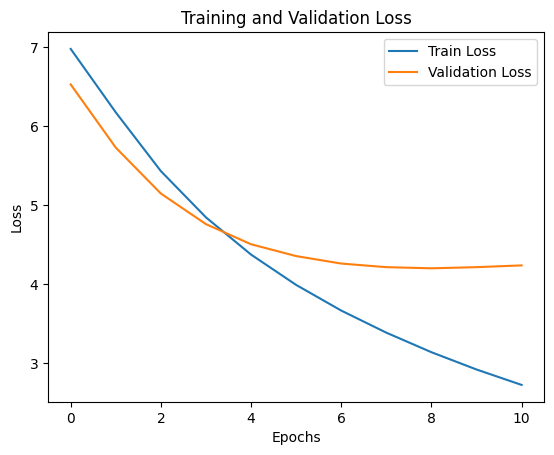

In [39]:
import matplotlib.pyplot as plt

plt.plot(range(len(train_losses)), train_losses, label='Train Loss')
plt.plot(range(len(val_losses)), val_losses, label='Validation Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

In [40]:
src_index_to_word = {idx: word for word, idx in src_vocab.items()} # 원문 단어 집합에서 정수 -> 단어를 얻음
tar_word_to_index = tar_vocab # 요약 단어 집합에서 단어 -> 정수를 얻음
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()} # 요약 단어 집합에서 정수 -> 단어를 얻음

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
decoder.to(device)

# 인코더 설계
def encode_input(encoder, input_seq):
    encoder_outputs, hidden, cell = encoder(input_seq)
    return encoder_outputs, hidden, cell


num_layers = 3
batch_size = 1

decoder_state_input_h = torch.zeros((num_layers, batch_size, hidden_size), dtype=torch.float, device=device)
decoder_state_input_c = torch.zeros((num_layers, batch_size, hidden_size), dtype=torch.float, device=device)
decoder_input = torch.zeros((batch_size, 1), dtype=torch.long, device=device)

dec_emb2 = decoder.embedding(decoder_input)

# 문장의 다음 단어를 예측하기 위해서 초기 상태(initial_state)를 이전 시점의 상태로 사용. 이는 뒤의 함수 decode_sequence()에 구현
# 훈련 과정에서와 달리 LSTM의 리턴하는 은닉 상태와 셀 상태인 state_h와 state_c를 버리지 않음.
decoder_outputs2, state_h2, state_c2 = decoder(decoder_input, decoder_state_input_h, decoder_state_input_c)

In [42]:
class DecoderWithAttention(nn.Module):
    def __init__(self, decoder, attention, hidden_size, vocab_size):
        super(DecoderWithAttention, self).__init__()
        self.decoder = decoder  # 기존 디코더
        self.attention = attention  # 어텐션 레이어
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 어텐션 결합 레이어
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 최종 출력층
        self.softmax = nn.Softmax(dim=-1)  # 소프트맥스

    def forward(self, decoder_inputs, decoder_hidden_state, decoder_state_h, decoder_state_c):
        # 디코더 실행
        decoder_outputs, state_h, state_c = self.decoder(decoder_inputs, decoder_state_h, decoder_state_c)

        # 어텐션 적용
        attn_out = self.attention(decoder_outputs, decoder_hidden_state)

        # 어텐션과 디코더 출력 결합
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))

        # 최종 출력층 적용
        decoder_outputs2 = self.softmax(self.output_layer(decoder_concat_output))

        return decoder_outputs2, state_h, state_c

# 기존 Attention 클래스 사용
attention_layer = Attention_dot(hidden_size)

# 디코더 모델 생성
decoder_model = DecoderWithAttention(decoder, attention_layer, hidden_size, tar_vocab_size)
print(decoder_model)

DecoderWithAttention(
  (decoder): Decoder(
    (embedding): Embedding(15000, 256)
    (lstm): LSTM(256, 512, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): Attention_dot(
    (attn): Linear(in_features=512, out_features=512, bias=True)
    (v): Linear(in_features=512, out_features=1, bias=False)
  )
  (concat): Linear(in_features=1024, out_features=512, bias=True)
  (output_layer): Linear(in_features=512, out_features=15000, bias=True)
  (softmax): Softmax(dim=-1)
)


In [43]:
def decode_sequence(input_seq, encoder, decoder, tar_word_to_index, tar_index_to_word, text_max_len, summary_max_len, device):
    # 입력을 PyTorch Tensor로 변환
    input_seq = torch.tensor(input_seq, dtype=torch.long, device=device)

    # 인코더 실행하여 초기 상태(hidden, cell) 얻기
    with torch.no_grad():
        e_out, e_h, e_c = encoder(input_seq)

    e_out = e_out.repeat(1, text_max_len, 1)  # 차원 조정 (np.tile 대신 repeat 사용)

    # <SOS>에 해당하는 토큰 생성
    target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
    target_seq[0, 0] = tar_word_to_index['sostoken']

    stop_condition = False
    decoded_sentence = ''

    while not stop_condition:
        # 디코더 실행
        with torch.no_grad():
            output_tokens, h, c = decoder(target_seq, e_h, e_c)

        # 가장 높은 확률을 가진 단어 선택
        sampled_token_index = torch.argmax(output_tokens[0, -1, :]).item()
        sampled_token = tar_index_to_word[sampled_token_index]

        if sampled_token != 'eostoken':
            decoded_sentence += ' ' + sampled_token

        # 종료 조건: <eos>에 도달하거나 최대 길이를 초과하면 중단
        if sampled_token == 'eostoken' or len(decoded_sentence.split()) >= (summary_max_len - 1):
            stop_condition = True

        # 길이가 1인 타겟 시퀀스를 업데이트
        target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
        target_seq[0, 0] = sampled_token_index

        # 상태 업데이트
        e_h, e_c = h, c

    return decoded_sentence


In [44]:
# 원문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2text(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0:  # 패딩(0) 제외
            temp = temp + src_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()

# 요약문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2summary(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0 and key != tar_word_to_index['sostoken'] and key != tar_word_to_index['eostoken']:
            temp = temp + tar_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()  # 양쪽 공백 제거

for i in range(50, 100):
    print("원문 :", seq2text(encoder_input_test[i]))
    print("실제 요약 :", seq2summary(decoder_input_test[i]))
    input_seq = torch.tensor(encoder_input_test[i], dtype=torch.long, device=device).unsqueeze(0)
    print("예측 요약 :", decode_sequence(input_seq, encoder, decoder, tar_word_to_index, tar_index_to_word, text_max_len, summary_max_len, device))
    print("\n")

원문 : riteish deshmukh revealed genelia souza wife talk two days shooting tujhe meri <UNK> father cm maharashtra first thing genelia asked security replied riteish added film marked bollywood debut
실제 요약 : genelia did not talk to me at first as my dad was cm riteish
예측 요약 :  news into loss gandhi salman loss loss ahead ahead will test test test lakh online


원문 : bcci friday took twitter share video former indian captain mahendra singh dhoni slamming similar shot like world cup winning six nets wankhede stadium msdhoni hits big one wankhede stadium <UNK> takes us back famous six read caption
실제 요약 : dhoni hits six similar to wc winning shot in nets
예측 요약 :  news big player player airport million says virat got need air chief air chief house


원문 : katrina kaif said career successful adding year really good added think ever feel per cent secure career rapidly changing industry however said feel comfortable confident industry
실제 요약 : have had successful career this year has been good katr

/tmp/ipykernel_16841/446570644.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_seq = torch.tensor(encoder_input_test[i], dtype=torch.long, device=device).unsqueeze(0)
/tmp/ipykernel_16841/3915422083.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_seq = torch.tensor(input_seq, dtype=torch.long, device=device)


예측 요약 :  post post post post post post post probe released probe lakh lakh lakh lakh lakh


원문 : stating people aware congress president rahul gandhi tricks madhya pradesh cm shivraj singh chouhan tuesday said rahul baba realise one cannot get votes sporting tilak one forehead election times added shrines place indulge cheap politics get votes
실제 요약 : cannot get votes just by sporting <UNK> mp cm to rahul
예측 요약 :  news sets salman months employees tv tv runs runs runs asked chief asked asked asked


원문 : actor amitabh bachchan took twitter share poem memory late actress sridevi added poem written poet <UNK> azmi time guru dutt demise narrated javed akhtar sridevi funeral held wednesday amitabh sridevi worked together films like <UNK> <UNK> <UNK>
실제 요약 : big shares poem in late actress sridevi memory
예측 요약 :  news board files player player employees could lakh lakh lakh lakh lakh lakh lakh lakh


원문 : vicky kaushal said brother sunny kaushal knew bollywood la la land father action direc

- 실제 요약과 예측 요약을 육안으로 봐도 결과가 이상하다고 보여짐.(같은 단어 반복 등)

In [45]:
data.head()

,headlines,text,decoder_input,decoder_target
0,upgrad learner switches to career in ml al wit...,saurav kant alumnus upgrad iiit pg program mac...,sostoken upgrad learner switches to career in ...,upgrad learner switches to career in ml al wit...
1,delhi techie wins free food from swiggy for on...,kunal shah credit card bill payment platform c...,sostoken delhi techie wins free food from swig...,delhi techie wins free food from swiggy for on...
2,new zealand end rohit sharma led india match w...,new zealand defeated india wickets fourth odi ...,sostoken new zealand end rohit sharma led indi...,new zealand end rohit sharma led india match w...
3,aegon life iterm insurance plan helps customer...,aegon life iterm insurance plan customers enjo...,sostoken aegon life iterm insurance plan helps...,aegon life iterm insurance plan helps customer...
4,have known hirani for yrs what if metoo claims...,speaking sexual harassment allegations rajkuma...,sostoken have known hirani for yrs what if met...,have known hirani for yrs what if metoo claims...


In [51]:
# !pip install evaluate rouge-score bert-score summa  # 필요시
import re
import pandas as pd
from summa.summarizer import summarize
from evaluate import load
import numpy as np

# 하이퍼파라미터
RATIO = 0.01     # 원문의 약 20% 문장을 추출
WORDS = None     # 단어 수 기준 요약을 쓰고 싶으면 정수로 지정(예: 30)

def safe_summa(text, ratio=RATIO, words=WORDS):
    """summa 요약 실패/빈출력 대비 안전 래퍼"""
    if not isinstance(text, str) or not text.strip():
        return ""
    try:
        out = summarize(text, ratio=ratio, words=words, split=False)
    except Exception:
        out = ""
    if not out or not out.strip():
        # Fallback: 문장 1~2개
        sents = re.split(r'(?<=[.!?])\s+', text.strip())
        out = " ".join(sents[:2]) if sents else text
    # 공백 정리
    return " ".join(out.split())

def run_summa_and_score(df, text_col="text", ref_col="headlines", bert_lang="en"):
    # 예측/정답 생성
    preds = [safe_summa(t) for t in df[text_col].astype(str).tolist()]
    refs  = [" ".join(str(r).split()) for r in df[ref_col].astype(str).tolist()]

    # ROUGE
    rouge = load("rouge")
    r = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    rouge_report = {k: round(v*100, 2) for k, v in r.items()}

    # BERTScore
    bertscore = load("bertscore")
    bs = bertscore.compute(predictions=preds, references=refs, lang=bert_lang)
    bert_p = round(float(np.mean(bs["precision"])) * 100, 2)
    bert_r = round(float(np.mean(bs["recall"])) * 100, 2)
    bert_f1 = round(float(np.mean(bs["f1"])) * 100, 2)

    # 출력
    print("=== ROUGE (%) ===")
    print(f"ROUGE-1: {rouge_report['rouge1']}")
    print(f"ROUGE-2: {rouge_report['rouge2']}")
    print(f"ROUGE-L: {rouge_report['rougeL']}")
    print(f"ROUGE-Lsum: {rouge_report.get('rougeLsum', 'N/A')}")
    print("\n=== BERTScore (%) ===")
    print(f"P: {bert_p}  R: {bert_r}  F1: {bert_f1}")

    return preds, refs, {"rouge": rouge_report, "bertscore": {"P": bert_p, "R": bert_r, "F1": bert_f1}}


data_tr, data_te = train_test_split(
    data,
    test_size=0.2,
    shuffle=True,
    random_state=42
)


preds = [safe_summa(t) for t in data_te['text'].astype(str).tolist()]
refs  = [" ".join(str(r).split()) for r in data_te['headlines'].astype(str).tolist()]

# preds, refs, scores = run_summa_and_score(data, text_col="text", ref_col="headlines", bert_lang="en")

In [52]:
for i in range(50, 100):
    print("\n실제 요약 :", refs[i])
    print("예측 요약 :", preds[i])


실제 요약 : genelia did not talk to me at first as my dad was cm riteish
예측 요약 : riteish deshmukh revealed genelia souza wife talk two days shooting tujhe meri kasam father cm maharashtra first thing genelia asked security replied riteish added film marked bollywood debut

실제 요약 : dhoni hits six similar to wc winning shot in nets
예측 요약 : bcci friday took twitter share video former indian captain mahendra singh dhoni slamming similar shot like world cup winning six nets wankhede stadium msdhoni hits big one wankhede stadium invariably takes us back famous six read caption

실제 요약 : have had successful career this year has been good katrina
예측 요약 : katrina kaif said career successful adding year really good added think ever feel per cent secure career rapidly changing industry however said feel comfortable confident industry

실제 요약 : evaporating water could power of us claims study
예측 요약 : columbia university researchers found harnessing energy evaporation country water reservoirs could prod

### 요약문 비교

##### 원문1:
riteish deshmukh revealed genelia souza wife talk two days shooting tujhe meri <UNK> father cm maharashtra first thing genelia asked security replied riteish added film marked bollywood debut
- 실제 요약: genelia did not talk to me at first as my dad was cm riteish
- Abstractive 요약: news into loss gandhi salman loss loss ahead ahead will test test test lakh online
- Extractive 요약: riteish deshmukh revealed genelia souza wife talk two days shooting tujhe meri kasam father cm maharashtra first thing genelia asked security replied riteish added film marked bollywood debut


##### 원문2:
bcci friday took twitter share video former indian captain mahendra singh dhoni slamming similar shot like world cup winning six nets wankhede stadium msdhoni hits big one wankhede stadium <UNK> takes us back famous six read caption
- 실제 요약: dhoni hits six similar to wc winning shot in nets
- Abstractive 요약: news big player player airport million says virat got need air chief air chief house
- Extractive 요약: bcci friday took twitter share video former indian captain mahendra singh dhoni slamming similar shot like world cup winning six nets wankhede stadium msdhoni hits big one wankhede stadium invariably takes us back famous six read caption


##### 원문3:
katrina kaif said career successful adding year really good added think ever feel per cent secure career rapidly changing industry however said feel comfortable confident industry
- 실제 요약: have had successful career this year has been good katrina
- Abstractive 요약: news for salman player for for they this this odi runs war air chief online
- Extractive 요약: katrina kaif said career successful adding year really good added think ever feel per cent secure career rapidly changing industry however said feel comfortable confident industry

| 예시  | 모델          | 코멘트                                 |
| --- | ----------- | ----------------------------------- |
| 원문1 | Abstractive | 무의미 토큰·반복(“news… loss… test…”)으로 비문 |
| 원문1 | Extractive  | 원문 문장 나열 수준, 연결·구두점 부족(가독성 낮음)      |
| 원문2 | Abstractive | 무관 단어 나열(“virat, air chief…”)       |
| 원문2 | Extractive  | 의미는 통하지만 과도하게 길고 구두점 없음(런온)         |
| 원문3 | Abstractive | 무관 토큰 반복(“salman… odi… online”)     |
| 원문3 | Extractive  | 핵심 문장 추출은 됐으나 연결·압축 부족              |


| 예시  | 모델          | 포함된 핵심                                    | 누락/왜곡                                              |
| --- | ----------- | ----------------------------------------- | -------------------------------------------------- |
| 원문1 | Abstractive | —                                         | Genelia/Riteish/CM, “did not talk at first” 모두 누락  |
| 원문1 | Extractive  | Genelia, Riteish, father/CM               | “처음에 말 안 했다” 핵심 관계는 직접적 표현 부족                      |
| 원문2 | Abstractive | —                                         | Dhoni, “hits six”, “WC winning shot”, “nets” 전부 누락 |
| 원문2 | Extractive  | Dhoni, similar shot, WC winning six, nets | —                                                  |
| 원문3 | Abstractive | —                                         | Katrina, “successful career”, “this year good” 누락  |
| 원문3 | Extractive  | Katrina, successful career, year good     | —                                                  |



In [53]:
# 전체적으로 Extractive 모델이 더 우수함
# 원인을 생각해보면,
# Attention 모델로 단어간의 관계를 충분히 학습하기에는 데이터가 부족
# 간단한 모델 구조, 학습루프로 현재 데이터에서조차 학습이 완벽하게 되지 않음 (summa는 정교하게 학습된 모델)
# 이 정도로 생각됨.
# Attention 모델의 size를 늘려도 결과는 달라지지 않았음